# Data Preparation

In [1]:
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
import glob

## Load Data

In [2]:
BASE_PATH = "../datasets/rakuten-france-multimodal-product-classification"

# Load feature data
X_train = pd.read_csv(f"{BASE_PATH}/X_train_update.csv")
X_test = pd.read_csv(f"{BASE_PATH}/X_test_update.csv")

# Load labels
Y_train = pd.read_csv(f"{BASE_PATH}/Y_train_CVw08PX.csv")

## Data Inspection

In [3]:
print("="*40)
print("Training Data Shape:", X_train.shape)
print("Test Data Shape:", X_test.shape)
print("Label Data Shape:", Y_train.shape)

# Display column-wise missing values
print("\nMissing Values in X_train:")
print(X_train.isnull().sum())

Training Data Shape: (84916, 5)
Test Data Shape: (13812, 5)
Label Data Shape: (84916, 2)

Missing Values in X_train:
Unnamed: 0         0
designation        0
description    29800
productid          0
imageid            0
dtype: int64


## Merge Features & Labels

In [4]:
merged_data = pd.concat([X_train, Y_train], axis=1)
print("\nMerged Data Columns:", merged_data.columns.tolist())

# Save merged data
os.makedirs("../datasets/processed/", exist_ok=True)
merged_data.to_csv("../datasets/processed/merged_data.csv", index=False)


Merged Data Columns: ['Unnamed: 0', 'designation', 'description', 'productid', 'imageid', 'Unnamed: 0', 'prdtypecode']


## Image Data Exploration

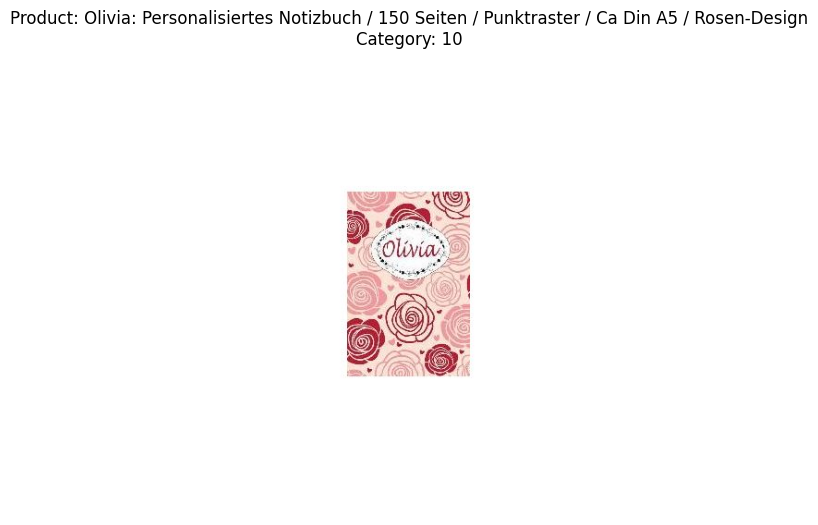

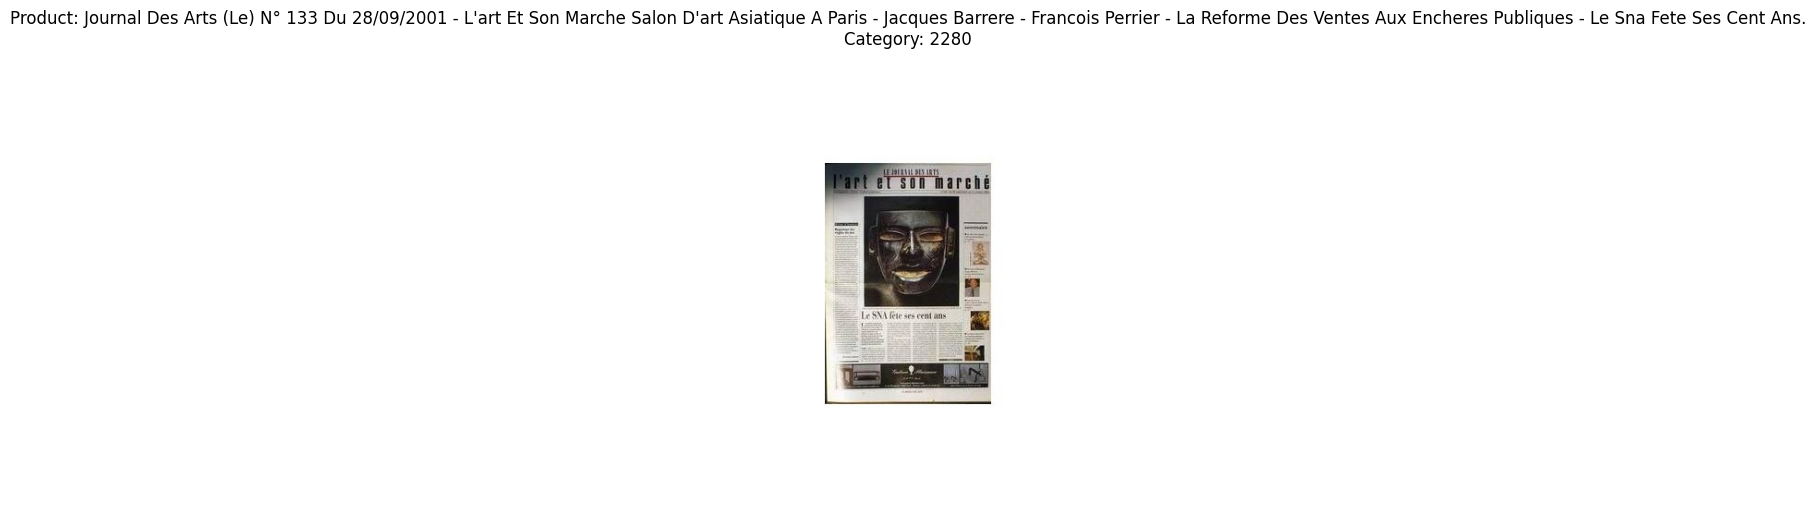

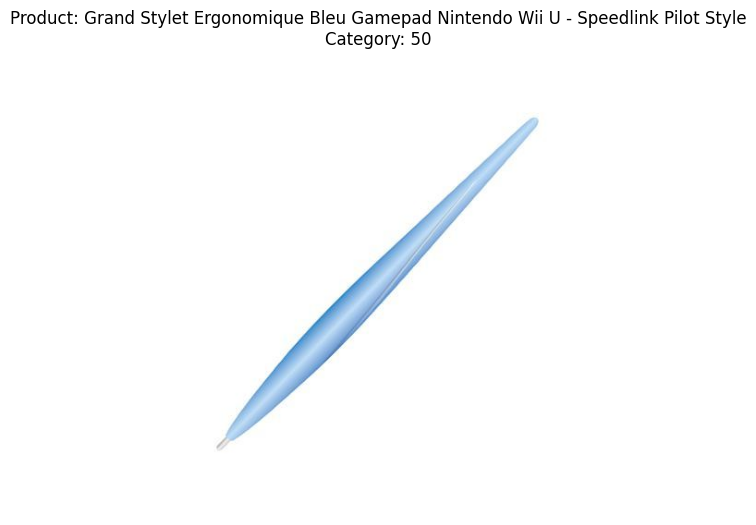

In [5]:
def display_sample_image(df, image_dir, idx=0):
    """Display image with error handling"""
    try:
        # Get the image_id from the dataframe
        image_id = str(df.iloc[idx]['imageid'])
        
        # Locate image file using image_id
        matching_files = glob.glob(os.path.join(image_dir, f"image_{image_id}_product_*.jpg"))
        
        if not matching_files:
            raise FileNotFoundError(f"Image {image_id} not found.")
        
        # Open and display the image
        img = Image.open(matching_files[0])
        plt.figure(figsize=(8,6))
        plt.imshow(img)
        plt.title(f"Product: {df.iloc[idx]['designation']}\nCategory: {df.iloc[idx]['prdtypecode']}")
        plt.axis('off')  # Hide axis for cleaner display
        plt.show()
        
    except Exception as e:
        print(f"Error loading image {image_id}: {str(e)}")

# Display first 3 training images
for i in range(3):
    display_sample_image(merged_data, f"{BASE_PATH}/images/image_train/", idx=i)

## Text Analysis


Text Length Statistics:
count    84916.000000
mean       595.719228
std        762.067621
min         12.000000
25%         66.000000
50%        314.000000
75%        904.000000
max      12536.000000
Name: text_length, dtype: float64


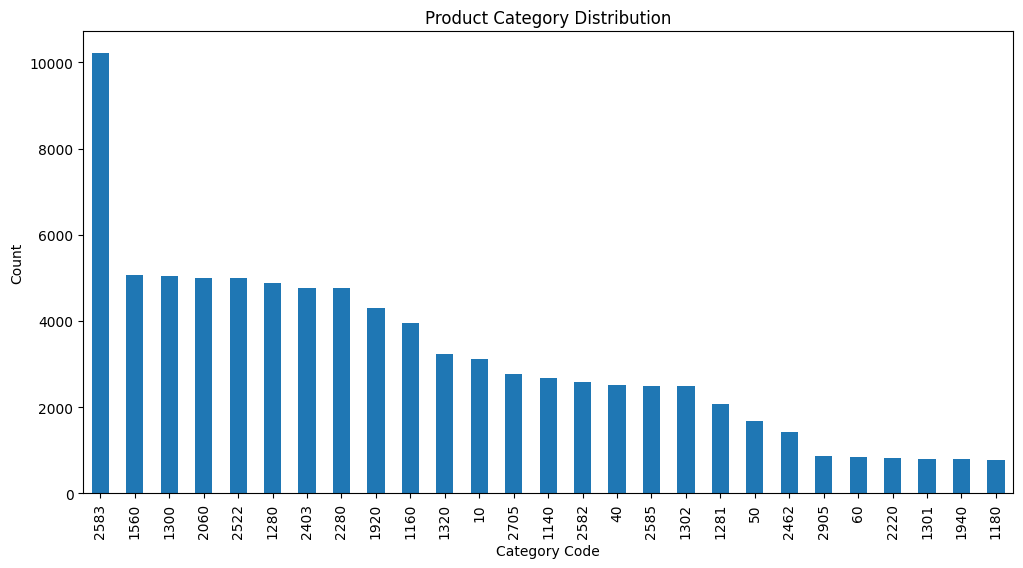

In [6]:
merged_data['full_text'] = merged_data['designation'] + " " + merged_data['description'].fillna('')

# Analyze text lengths
merged_data['text_length'] = merged_data['full_text'].apply(len)
print("\nText Length Statistics:")
print(merged_data['text_length'].describe())

# Plot category distribution
plt.figure(figsize=(12,6))
merged_data['prdtypecode'].value_counts().plot(kind='bar')
plt.title('Product Category Distribution')
plt.xlabel('Category Code')
plt.ylabel('Count')
plt.show()